## Pipeline XGBoost por poço - Modelo preditivo de profundidade de água subterrânea

**Objetivo:** Modelar e prever a profundidade do nível de água subterrânea (`profundidade`) por poço (`codigo`) usando modelos de regressão XGBoost com variáveis exógenas e divisão temporal (train/test no tempo).

### Características principais
- **Mesma estrutura de dados do `modelo1.ipynb`** (mesmo CSV, mesmas colunas, mesmo pré-processamento mensal por poço).
- **Variável alvo:** `profundidade` (metros).
- **Variáveis exógenas:** apenas os 6 lags (`rr_lag1`, `rr_lag2`, `eto_lag1`, `eto_lag2`, `caudal_lag1`, `caudal_lag2`).
- **Split temporal:** últimos 20% dos dados de cada poço para teste.
- **Modelo:** `XGBRegressor` por poço (um modelo por `codigo`).
- **Baseline:** persistência (prevê sempre o valor anterior `y_{t-1}`).
- **Métricas:** RMSE, MAE, MAPE, R² e comparação com baseline.

### 🆕 Melhorias implementadas com Cross-Validation
- **Time Series Cross-Validation:** avaliação robusta respeitando ordem temporal (nunca usa dados futuros)
- **Seleção de features por poço:** cada poço tem suas próprias features otimizadas usando CV
- **Tuning de hiperparâmetros por poço:** hiperparâmetros ajustados individualmente para cada poço usando CV
- **Comparação automática:** compara modelo otimizado vs modelo original para medir melhorias



In [14]:
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise ImportError(
        "xgboost é necessário para este notebook. Instale com: pip install xgboost"
    ) from e

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error"""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Absolute Percentage Error (em percentagem)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def r2_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """R² Score (coeficiente de determinação)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return float(1 - (ss_res / ss_tot))



In [15]:
# Configuração

CSV_PATH = "/Users/diogopinto/Documents/Pessoal/path_4med/eobs_netcdf/usar_model/correlacao_matriz/modelo_1/mensal_por_poco_full_valores_lags_este.csv"

# Colunas principais
ID_COL = "codigo"
DATE_COL = "ym"
TARGET_COL = "profundidade"

# Lista de poços a modelar (os restantes serão ignorados)
SELECTED_WELLS = [
    "391/33",
    "377/94",
    "330/183",
    "405/17",
    "377/86",
    "341/17",
    "418/4",
    "391/437",
    "404/69",
    "391/243",
    "342/78",
    "331/2",
    "405/34",
    "390/208",
    "377/54",
    "342/97",
    "377/84",
]

# Variáveis exógenas: APENAS os 6 lags (rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caudal_lag2)
XREG_COLS = [
    "rr_lag1", "rr_lag2",
    "eto_lag1", "eto_lag2",
    "caudal_lag1", "caudal_lag2",
]

# Variáveis base (apenas para interpolação se necessário, mas não usadas diretamente no modelo)
BASE_EXOG_COLS = ["rr", "eto", "caudal"]

# Parâmetros gerais
TEST_FRACTION = 0.20   # últimos 20% para teste
MIN_SERIES_LENGTH = 24 # mínimo de observações por poço
SEASONAL_PERIOD = 12   # mantido apenas para referência (não usado diretamente pelo XGBoost)

RANDOM_SEED = 42
N_JOBS = -1

# Hiperparâmetros padrão do XGBoost (podem ser ajustados)
XGB_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_SEED,
    n_jobs=N_JOBS,
)



In [16]:
# Carregamento e preparação dos dados (mesma lógica do modelo1)

# 1) Ler CSV

df = pd.read_csv(CSV_PATH)

# Converter coluna de data se necessário
if not np.issubdtype(df[DATE_COL].dtype, np.datetime64):
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

# Selecionar e ordenar colunas relevantes
expected_cols = [ID_COL, DATE_COL, TARGET_COL] + XREG_COLS + BASE_EXOG_COLS
missing_cols = [c for c in expected_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Colunas em falta no CSV: {missing_cols}")

# Subconjunto de colunas necessárias
df = df[[ID_COL, DATE_COL, TARGET_COL] + XREG_COLS + BASE_EXOG_COLS].copy()
df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

print(f"CSV carregado: {len(df)} linhas, {df[ID_COL].nunique()} poços únicos")
print(f"Variáveis exógenas para o modelo (lags): {XREG_COLS}")

# 2) Funções para verificar gaps mensais e fazer reindex mensal por poço

def has_month_gaps(group: pd.DataFrame) -> bool:
    dates = group[DATE_COL].sort_values()
    if dates.empty:
        return False
    start = dates.min().to_period("M")
    end = dates.max().to_period("M")
    full = pd.period_range(start, end, freq="M")
    return len(dates) != len(full)


wells_with_gaps = df.groupby(ID_COL, group_keys=False)[DATE_COL].apply(
    lambda dates: has_month_gaps(pd.DataFrame({DATE_COL: dates}))
)
num_wells_with_gaps = int(wells_with_gaps.sum())


def reindex_monthly(group: pd.DataFrame) -> pd.DataFrame:
    dates = group[DATE_COL].sort_values()
    if dates.empty:
        return group
    start = dates.min().to_period("M").to_timestamp()
    end = dates.max().to_period("M").to_timestamp()
    full_idx = pd.date_range(start, end, freq="MS")

    codigo_val = group[ID_COL].iloc[0]

    g2 = group.set_index(DATE_COL).reindex(full_idx)
    g2.index.name = DATE_COL
    g2[ID_COL] = codigo_val
    return g2.reset_index()


# 3) Reindex mensal por poço

df_list = []
for codigo, group in df.groupby(ID_COL, group_keys=False):
    reindexed = reindex_monthly(group)
    df_list.append(reindexed)

df = pd.concat(df_list, ignore_index=True)
df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

# 4) Tratar NAs

# 4.1) Interpolar variáveis base (rr, eto, caudal) se necessário
for c in BASE_EXOG_COLS:
    if c in df.columns:
        df[c] = (
            df.groupby(ID_COL, group_keys=False)[c]
              .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
        )

# 4.2) Remover linhas com NA nas variáveis de lag (XREG_COLS)
df = df.dropna(subset=XREG_COLS)

# 4.3) Remover linhas com NA na variável alvo
df = df.dropna(subset=[TARGET_COL])

# 5) Ordenar e filtrar apenas poços selecionados

df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

if SELECTED_WELLS:
    df = df[df[ID_COL].isin(SELECTED_WELLS)].copy()

print({
    "rows_after_clean": len(df),
    "unique_wells": df[ID_COL].nunique(),
    "wells_with_gaps_pre_reindex": num_wells_with_gaps,
    "filtered_wells": df[ID_COL].nunique(),
})

df.head()



CSV carregado: 22119 linhas, 73 poços únicos
Variáveis exógenas para o modelo (lags): ['rr_lag1', 'rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2']
{'rows_after_clean': 2356, 'unique_wells': 17, 'wells_with_gaps_pre_reindex': 0, 'filtered_wells': 17}


,ym,codigo,profundidade,rr_lag1,rr_lag2,eto_lag1,eto_lag2,caudal_lag1,caudal_lag2,rr,eto,caudal
15,2000-03-01,330/183,7.46,1.900000,23.800002,2.128276,1.373548,90.410000,185.302903,28.200000,3.239677,66.979677
16,2000-04-01,330/183,7.29,28.200000,1.900000,3.239677,2.128276,66.979677,90.410000,175.200004,2.909667,144.695000
17,2000-05-01,330/183,6.66,175.200004,28.200000,2.909667,3.239677,144.695000,66.979677,87.600002,4.611613,356.501613
18,2000-06-01,330/183,7.50,87.600002,175.200004,4.611613,2.909667,356.501613,144.695000,0.000000,6.125667,78.218667
19,2000-07-01,330/183,8.40,0.000000,87.600002,6.125667,4.611613,78.218667,356.501613,9.200000,6.178387,82.856129


In [17]:
# Resumo das variáveis usadas no modelo XGBoost

print("\n" + "=" * 60)
print("CONFIGURAÇÃO DO MODELO XGBOOST")
print("=" * 60)
print(f"Variáveis exógenas usadas (lags): {XREG_COLS}")
print(f"Total de variáveis exógenas: {len(XREG_COLS)}")
print(f"Variável alvo: {TARGET_COL}")
print(f"Poços seleccionados: {len(SELECTED_WELLS)}")
print(f"CSV: {CSV_PATH}")

print("\nHiperparâmetros XGBoost (padrão):")
for k, v in XGB_PARAMS.items():
    print(f"  {k}: {v}")




CONFIGURAÇÃO DO MODELO XGBOOST
Variáveis exógenas usadas (lags): ['rr_lag1', 'rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2']
Total de variáveis exógenas: 6
Variável alvo: profundidade
Poços seleccionados: 17
CSV: /Users/diogopinto/Documents/Pessoal/path_4med/eobs_netcdf/usar_model/correlacao_matriz/modelo_1/mensal_por_poco_full_valores_lags_este.csv

Hiperparâmetros XGBoost (padrão):
  n_estimators: 500
  learning_rate: 0.05
  max_depth: 4
  subsample: 0.8
  colsample_bytree: 0.8
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1


In [18]:
# Helpers: split temporal e treino/predição com XGBoost


def temporal_split(group: pd.DataFrame, test_fraction: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Divide um DataFrame em treino e teste, mantendo ordem temporal."""
    n = len(group)
    n_test = max(1, int(round(n * test_fraction)))
    split_idx = n - n_test
    return group.iloc[:split_idx].copy(), group.iloc[split_idx:].copy()


def fit_predict_xgboost(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = TARGET_COL,
    xgb_params: dict | None = None,
):
    """Ajusta um XGBRegressor e devolve o modelo e previsões para o conjunto de teste."""
    if xgb_params is None:
        xgb_params = XGB_PARAMS

    X_train = train_df[feature_cols].to_numpy()
    y_train = train_df[target_col].to_numpy()
    X_test = test_df[feature_cols].to_numpy()

    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    return model, np.asarray(y_pred)



In [19]:
# ============================================================================
# TIME SERIES CROSS-VALIDATION E OTIMIZAÇÃO POR POÇO
# ============================================================================
# Esta célula implementa:
# 1. Time Series Cross-Validation (respeitando ordem temporal)
# 2. Seleção de features por poço (cada poço pode ter features diferentes)
# 3. Tuning básico de hiperparâmetros usando CV
# ============================================================================

from itertools import combinations
from sklearn.model_selection import TimeSeriesSplit

# Configurações de CV e otimização
CV_N_SPLITS = 5  # número de splits para cross-validation
MIN_TRAIN_SIZE = 12  # tamanho mínimo do conjunto de treino em cada split
MIN_FEATURES = 2  # número mínimo de features a testar
MAX_FEATURES_TO_TEST = 6  # número máximo de combinações de features a testar (para não demorar muito)

# Espaço de hiperparâmetros para tuning (por poço)
HYPERPARAM_GRID = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500, 700],
    'subsample': [0.7, 0.8, 0.9],
}

print("=" * 60)
print("CONFIGURAÇÃO DE CROSS-VALIDATION E OTIMIZAÇÃO")
print("=" * 60)
print(f"Número de splits CV: {CV_N_SPLITS}")
print(f"Tamanho mínimo de treino por split: {MIN_TRAIN_SIZE}")
print(f"Features mínimas por modelo: {MIN_FEATURES}")
print(f"Espaço de hiperparâmetros: {len(HYPERPARAM_GRID['max_depth']) * len(HYPERPARAM_GRID['learning_rate']) * len(HYPERPARAM_GRID['n_estimators']) * len(HYPERPARAM_GRID['subsample'])} combinações")

def time_series_cv_split(n_samples, n_splits=CV_N_SPLITS, min_train_size=MIN_TRAIN_SIZE):
    """
    Gera splits temporais para cross-validation.
    Garante que nunca usa dados futuros para prever o passado.
    """
    splits = []
    # Garantir que temos dados suficientes
    if n_samples < min_train_size + 1:
        return splits
    
    # Calcular tamanho mínimo do teste (pelo menos 1)
    min_test_size = max(1, n_samples // (n_splits + 1))
    
    for i in range(n_splits):
        # Tamanho do conjunto de treino aumenta a cada split
        train_size = min_train_size + i * (n_samples - min_train_size) // n_splits
        test_size = min_test_size
        
        # Garantir que não ultrapassamos o tamanho total
        if train_size + test_size > n_samples:
            break
            
        test_start = train_size
        test_end = min(train_size + test_size, n_samples)
        
        if test_end > test_start:
            splits.append((train_size, test_start, test_end))
    
    return splits


def evaluate_model_cv(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    xgb_params: dict,
    n_splits: int = CV_N_SPLITS,
) -> dict:
    """
    Avalia um modelo usando Time Series Cross-Validation.
    Retorna métricas médias e desvios padrão.
    """
    n_samples = len(X)
    splits = time_series_cv_split(n_samples, n_splits)
    
    if not splits:
        return {
            'rmse_mean': np.nan,
            'rmse_std': np.nan,
            'mae_mean': np.nan,
            'mae_std': np.nan,
            'r2_mean': np.nan,
            'r2_std': np.nan,
            'n_splits': 0,
        }
    
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    
    for train_size, test_start, test_end in splits:
        X_train = X[:train_size]
        y_train = y[:train_size]
        X_test = X[test_start:test_end]
        y_test = y[test_start:test_end]
        
        if len(X_train) < MIN_TRAIN_SIZE or len(X_test) < 1:
            continue
        
        try:
            model = XGBRegressor(**xgb_params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            rmse_scores.append(rmse(y_test, y_pred))
            mae_scores.append(mean_absolute_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))
        except Exception:
            continue
    
    if not rmse_scores:
        return {
            'rmse_mean': np.nan,
            'rmse_std': np.nan,
            'mae_mean': np.nan,
            'mae_std': np.nan,
            'r2_mean': np.nan,
            'r2_std': np.nan,
            'n_splits': 0,
        }
    
    return {
        'rmse_mean': float(np.mean(rmse_scores)),
        'rmse_std': float(np.std(rmse_scores)),
        'mae_mean': float(np.mean(mae_scores)),
        'mae_std': float(np.std(mae_scores)),
        'r2_mean': float(np.mean(r2_scores)),
        'r2_std': float(np.std(r2_scores)),
        'n_splits': len(rmse_scores),
    }


def select_features_for_well(
    g: pd.DataFrame,
    all_features: list[str],
    target_col: str = TARGET_COL,
    max_combinations: int = MAX_FEATURES_TO_TEST,
) -> tuple[list[str], dict]:
    """
    Seleciona as melhores features para um poço específico usando CV.
    Testa diferentes combinações de features e retorna a melhor.
    """
    available_features = [f for f in all_features if f in g.columns and not g[f].isna().all()]
    
    if len(available_features) < MIN_FEATURES:
        return available_features, {'rmse_mean': np.nan}
    
    # Preparar dados
    X_all = g[available_features].to_numpy()
    y_all = g[target_col].to_numpy()
    
    if len(X_all) < MIN_TRAIN_SIZE + 1:
        return available_features, {'rmse_mean': np.nan}
    
    best_features = available_features
    best_score = {'rmse_mean': np.inf}
    
    # Testar todas as features primeiro
    score_all = evaluate_model_cv(X_all, y_all, available_features, XGB_PARAMS, CV_N_SPLITS)
    if not np.isnan(score_all['rmse_mean']) and score_all['rmse_mean'] < best_score['rmse_mean']:
        best_score = score_all
        best_features = available_features
    
    # Testar combinações menores (se não tiver muitas features)
    if len(available_features) <= 6:
        # Testar todas as combinações de tamanho MIN_FEATURES até len(available_features)-1
        for r in range(MIN_FEATURES, len(available_features)):
            for combo in combinations(available_features, r):
                if len(combo) < MIN_FEATURES:
                    continue
                
                X_subset = g[list(combo)].to_numpy()
                score = evaluate_model_cv(X_subset, y_all, list(combo), XGB_PARAMS, CV_N_SPLITS)
                
                if not np.isnan(score['rmse_mean']) and score['rmse_mean'] < best_score['rmse_mean']:
                    best_score = score
                    best_features = list(combo)
    else:
        # Se tiver muitas features, testar apenas algumas combinações estratégicas
        # Testar sem cada feature individualmente
        for feature_to_remove in available_features:
            combo = [f for f in available_features if f != feature_to_remove]
            if len(combo) < MIN_FEATURES:
                continue
            
            X_subset = g[combo].to_numpy()
            score = evaluate_model_cv(X_subset, y_all, combo, XGB_PARAMS, CV_N_SPLITS)
            
            if not np.isnan(score['rmse_mean']) and score['rmse_mean'] < best_score['rmse_mean']:
                best_score = score
                best_features = combo
    
    return best_features, best_score


def tune_hyperparameters_for_well(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    param_grid: dict = HYPERPARAM_GRID,
    n_splits: int = CV_N_SPLITS,
    max_combinations: int = 20,  # limitar para não demorar muito
) -> tuple[dict, dict]:
    """
    Faz tuning básico de hiperparâmetros usando CV.
    Testa um subconjunto do espaço de parâmetros e retorna os melhores.
    """
    best_params = XGB_PARAMS.copy()
    best_score = {'rmse_mean': np.inf}
    
    # Gerar combinações de hiperparâmetros
    combinations_tested = 0
    for max_depth in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:
            for n_est in param_grid['n_estimators']:
                for subsample in param_grid['subsample']:
                    if combinations_tested >= max_combinations:
                        break
                    
                    params = XGB_PARAMS.copy()
                    params.update({
                        'max_depth': max_depth,
                        'learning_rate': lr,
                        'n_estimators': n_est,
                        'subsample': subsample,
                    })
                    
                    score = evaluate_model_cv(X, y, feature_names, params, n_splits)
                    
                    if not np.isnan(score['rmse_mean']) and score['rmse_mean'] < best_score['rmse_mean']:
                        best_score = score
                        best_params = params.copy()
                    
                    combinations_tested += 1
                
                if combinations_tested >= max_combinations:
                    break
            if combinations_tested >= max_combinations:
                break
        if combinations_tested >= max_combinations:
            break
    
    return best_params, best_score


print("\nFunções de CV e otimização definidas com sucesso!")
print(f"  - time_series_cv_split(): gera splits temporais")
print(f"  - evaluate_model_cv(): avalia modelo com CV")
print(f"  - select_features_for_well(): seleciona melhores features por poço")
print(f"  - tune_hyperparameters_for_well(): ajusta hiperparâmetros por poço")



CONFIGURAÇÃO DE CROSS-VALIDATION E OTIMIZAÇÃO
Número de splits CV: 5
Tamanho mínimo de treino por split: 12
Features mínimas por modelo: 2
Espaço de hiperparâmetros: 108 combinações

Funções de CV e otimização definidas com sucesso!
  - time_series_cv_split(): gera splits temporais
  - evaluate_model_cv(): avalia modelo com CV
  - select_features_for_well(): seleciona melhores features por poço
  - tune_hyperparameters_for_well(): ajusta hiperparâmetros por poço


In [20]:
# ============================================================================
# LOOP DE MODELAÇÃO MELHORADO COM CV, FEATURE SELECTION E HYPERPARAMETER TUNING
# ============================================================================
# Este loop:
# 1. Seleciona as melhores features para cada poço usando CV
# 2. Ajusta hiperparâmetros específicos para cada poço usando CV
# 3. Treina modelo final e avalia no conjunto de teste
# 4. Compara com modelo original (sem otimização)
# ============================================================================

print("=" * 60)
print("INICIANDO MODELAÇÃO OTIMIZADA COM CROSS-VALIDATION")
print("=" * 60)
print(f"Processando {df[ID_COL].nunique()} poços...")
print("Este processo pode demorar alguns minutos devido ao CV e otimização.\n")

results_optimized = []
results_original = []  # para comparação
failed_wells = []
feature_selections = []  # guarda quais features foram selecionadas por poço
hyperparams_optimized = []  # guarda hiperparâmetros otimizados por poço

for codigo, g in tqdm(df.groupby(ID_COL), total=df[ID_COL].nunique(), desc="Processando poços"):
    g = g.sort_values(DATE_COL).reset_index(drop=True)
    
    if len(g) < MIN_SERIES_LENGTH:
        continue
    
    # Verificar features disponíveis
    available_features = [c for c in XREG_COLS if c in g.columns]
    if not available_features or len(available_features) < MIN_FEATURES:
        continue
    
    # Garantir que não existem NAs
    if g[available_features + [TARGET_COL]].isna().any().any():
        continue
    
    try:
        # ====================================================================
        # ETAPA 1: SELEÇÃO DE FEATURES usando CV
        # ====================================================================
        print(f"\n[{codigo}] Selecionando features...")
        best_features, feature_cv_score = select_features_for_well(g, XREG_COLS, TARGET_COL)
        
        if not best_features or np.isnan(feature_cv_score.get('rmse_mean', np.nan)):
            print(f"  ⚠️  Não foi possível selecionar features, usando todas disponíveis")
            best_features = available_features
        else:
            print(f"  ✅ Features selecionadas: {best_features}")
            print(f"     RMSE CV (feature selection): {feature_cv_score['rmse_mean']:.4f} ± {feature_cv_score['rmse_std']:.4f}")
        
        # ====================================================================
        # ETAPA 2: TUNING DE HIPERPARÂMETROS usando CV
        # ====================================================================
        print(f"[{codigo}] Ajustando hiperparâmetros...")
        X_all = g[best_features].to_numpy()
        y_all = g[TARGET_COL].to_numpy()
        
        best_params, hyperparam_cv_score = tune_hyperparameters_for_well(
            X_all, y_all, best_features, HYPERPARAM_GRID, CV_N_SPLITS, max_combinations=20
        )
        
        if np.isnan(hyperparam_cv_score.get('rmse_mean', np.nan)):
            print(f"  ⚠️  Tuning falhou, usando parâmetros padrão")
            best_params = XGB_PARAMS.copy()
        else:
            print(f"  ✅ Hiperparâmetros otimizados:")
            print(f"     max_depth={best_params['max_depth']}, lr={best_params['learning_rate']:.3f}, "
                  f"n_est={best_params['n_estimators']}, subsample={best_params['subsample']:.2f}")
            print(f"     RMSE CV (hyperparameter tuning): {hyperparam_cv_score['rmse_mean']:.4f} ± {hyperparam_cv_score['rmse_std']:.4f}")
        
        # ====================================================================
        # ETAPA 3: TREINO FINAL E AVALIAÇÃO NO TESTE
        # ====================================================================
        train_df, test_df = temporal_split(g, TEST_FRACTION)
        
        y_train = train_df[TARGET_COL].to_numpy()
        y_test = test_df[TARGET_COL].to_numpy()
        
        if len(y_test) < 2:
            continue
        
        # Modelo OTIMIZADO (com features selecionadas e hiperparâmetros ajustados)
        X_train_opt = train_df[best_features].to_numpy()
        X_test_opt = test_df[best_features].to_numpy()
        
        model_optimized = XGBRegressor(**best_params)
        model_optimized.fit(X_train_opt, y_train)
        y_pred_optimized = model_optimized.predict(X_test_opt)
        
        # Modelo ORIGINAL (para comparação - todas features, parâmetros padrão)
        X_train_orig = train_df[available_features].to_numpy()
        X_test_orig = test_df[available_features].to_numpy()
        
        model_original = XGBRegressor(**XGB_PARAMS)
        model_original.fit(X_train_orig, y_train)
        y_pred_original = model_original.predict(X_test_orig)
        
        # Baseline de persistência
        y_pred_persist = np.r_[y_train[-1], y_test[:-1]]
        
        # ====================================================================
        # ETAPA 4: CÁLCULO DE MÉTRICAS
        # ====================================================================
        # Métricas do modelo OTIMIZADO
        rmse_opt = rmse(y_test, y_pred_optimized)
        mae_opt = float(mean_absolute_error(y_test, y_pred_optimized))
        mape_opt = mape(y_test, y_pred_optimized)
        r2_opt = r2_score(y_test, y_pred_optimized)
        
        # Métricas do modelo ORIGINAL
        rmse_orig = rmse(y_test, y_pred_original)
        mae_orig = float(mean_absolute_error(y_test, y_pred_original))
        mape_orig = mape(y_test, y_pred_original)
        r2_orig = r2_score(y_test, y_pred_original)
        
        # Métricas do baseline
        rmse_base = rmse(y_test, y_pred_persist)
        mae_base = float(mean_absolute_error(y_test, y_pred_persist))
        mape_base = mape(y_test, y_pred_persist)
        r2_base = r2_score(y_test, y_pred_persist)
        
        # ====================================================================
        # ETAPA 5: GUARDAR RESULTADOS
        # ====================================================================
        # Resultados do modelo OTIMIZADO
        res_opt = {
            ID_COL: codigo,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "n_vars": len(best_features),
            "features_selected": ", ".join(best_features),
            "RMSE": rmse_opt,
            "MAE": mae_opt,
            "MAPE": mape_opt,
            "R2": r2_opt,
            "RMSE_baseline": rmse_base,
            "MAE_baseline": mae_base,
            "MAPE_baseline": mape_base,
            "R2_baseline": r2_base,
            "RMSE_gain": rmse_base - rmse_opt,
            "MAE_gain": mae_base - mae_opt,
            "MAPE_gain": mape_base - mape_opt,
            "R2_gain": r2_opt - r2_base,
            "RMSE_improvement_vs_original": rmse_orig - rmse_opt,  # quanto melhorou vs original
            "MAE_improvement_vs_original": mae_orig - mae_opt,
            "R2_improvement_vs_original": r2_opt - r2_orig,
            "model_type": "XGBoost_Optimized",
            "max_depth": best_params.get("max_depth"),
            "learning_rate": best_params.get("learning_rate"),
            "n_estimators": best_params.get("n_estimators"),
            "subsample": best_params.get("subsample"),
            "cv_rmse_mean": feature_cv_score.get('rmse_mean', np.nan),
            "cv_rmse_std": feature_cv_score.get('rmse_std', np.nan),
            "cv_n_splits": feature_cv_score.get('n_splits', 0),
        }
        results_optimized.append(res_opt)
        
        # Resultados do modelo ORIGINAL (para comparação)
        res_orig = {
            ID_COL: codigo,
            "RMSE": rmse_orig,
            "MAE": mae_orig,
            "MAPE": mape_orig,
            "R2": r2_orig,
            "model_type": "XGBoost_Original",
        }
        results_original.append(res_orig)
        
        # Guardar seleção de features
        feature_selections.append({
            ID_COL: codigo,
            "features_selected": ", ".join(best_features),
            "n_features": len(best_features),
            "all_available": ", ".join(available_features),
        })
        
        # Guardar hiperparâmetros otimizados
        hyperparams_optimized.append({
            ID_COL: codigo,
            **{k: v for k, v in best_params.items() if k in ['max_depth', 'learning_rate', 'n_estimators', 'subsample']}
        })
        
        print(f"[{codigo}] ✅ Concluído!")
        print(f"     RMSE Otimizado: {rmse_opt:.4f} | Original: {rmse_orig:.4f} | Melhoria: {rmse_orig - rmse_opt:.4f}")
        
    except Exception as e:
        failed_wells.append((codigo, str(e)))
        print(f"[{codigo}] ❌ Erro: {str(e)[:100]}")
        continue

# Criar DataFrames com resultados
metrics_optimized_df = pd.DataFrame(results_optimized).sort_values("RMSE").reset_index(drop=True)
metrics_original_df = pd.DataFrame(results_original)
feature_selection_df = pd.DataFrame(feature_selections)
hyperparams_df = pd.DataFrame(hyperparams_optimized)

print("\n" + "=" * 60)
print("RESUMO DA MODELAÇÃO OTIMIZADA")
print("=" * 60)
print(f"Poços modelados com sucesso: {len(metrics_optimized_df)}")
print(f"Poços com falha: {len(failed_wells)}")

if failed_wells:
    print("\nPoços com falha (primeiros 5):")
    for codigo, error in failed_wells[:5]:
        print(f"  - {codigo}: {error[:120]}")

print("\n" + "=" * 60)
print("ESTATÍSTICAS DAS MÉTRICAS - MODELO OTIMIZADO")
print("=" * 60)
if len(metrics_optimized_df) > 0:
    print(f"RMSE médio: {metrics_optimized_df['RMSE'].mean():.4f} ± {metrics_optimized_df['RMSE'].std():.4f}")
    print(f"MAE médio: {metrics_optimized_df['MAE'].mean():.4f} ± {metrics_optimized_df['MAE'].std():.4f}")
    print(f"MAPE médio: {metrics_optimized_df['MAPE'].mean():.2f}% ± {metrics_optimized_df['MAPE'].std():.2f}%")
    print(f"R² médio: {metrics_optimized_df['R2'].mean():.4f} ± {metrics_optimized_df['R2'].std():.4f}")

print("\n" + "=" * 60)
print("COMPARAÇÃO: OTIMIZADO vs ORIGINAL")
print("=" * 60)
if len(metrics_optimized_df) > 0 and len(metrics_original_df) > 0:
    merged = metrics_optimized_df.merge(metrics_original_df, on=ID_COL, suffixes=('_opt', '_orig'))
    print(f"Melhoria média em RMSE: {merged['RMSE_improvement_vs_original'].mean():.4f}")
    print(f"  - Poços que melhoraram: {(merged['RMSE_improvement_vs_original'] > 0).sum()} / {len(merged)}")
    print(f"  - Poços que pioraram: {(merged['RMSE_improvement_vs_original'] <= 0).sum()} / {len(merged)}")
    print(f"Melhoria média em MAE: {merged['MAE_improvement_vs_original'].mean():.4f}")
    print(f"Melhoria média em R²: {merged['R2_improvement_vs_original'].mean():.4f}")

print("\n" + "=" * 60)
print("TOP 10 MELHORES MODELOS OTIMIZADOS (menor RMSE)")
print("=" * 60)
if len(metrics_optimized_df) > 0:
    display(metrics_optimized_df.head(10)[[ID_COL, 'n_vars', 'RMSE', 'MAE', 'MAPE', 'R2', 
                                          'RMSE_improvement_vs_original', 'features_selected']])

metrics_optimized_df



INICIANDO MODELAÇÃO OTIMIZADA COM CROSS-VALIDATION
Processando 17 poços...
Este processo pode demorar alguns minutos devido ao CV e otimização.



Processando poços:   0%|          | 0/17 [00:00<?, ?it/s]


[330/183] Selecionando features...
  ✅ Features selecionadas: ['rr_lag1', 'rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2']
     RMSE CV (feature selection): 3.0275 ± 1.1266
[330/183] Ajustando hiperparâmetros...
  ✅ Hiperparâmetros otimizados:
     max_depth=3, lr=0.010, n_est=300, subsample=0.70
     RMSE CV (hyperparameter tuning): 2.8047 ± 1.2312
[330/183] ✅ Concluído!
     RMSE Otimizado: 1.7447 | Original: 2.0854 | Melhoria: 0.3407

[331/2] Selecionando features...
  ✅ Features selecionadas: ['rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2']
     RMSE CV (feature selection): 0.7530 ± 0.2672
[331/2] Ajustando hiperparâmetros...
  ✅ Hiperparâmetros otimizados:
     max_depth=3, lr=0.010, n_est=300, subsample=0.70
     RMSE CV (hyperparameter tuning): 0.7239 ± 0.2748
[331/2] ✅ Concluído!
     RMSE Otimizado: 0.6483 | Original: 0.6718 | Melhoria: 0.0236

[341/17] Selecionando features...
  ✅ Features selecionadas: ['rr_lag2', 'eto_lag1', 'eto_lag2', 'ca

,codigo,n_vars,RMSE,MAE,MAPE,R2,RMSE_improvement_vs_original,features_selected
0,405/17,2,0.210015,0.171096,17.676567,0.695601,0.029504,"eto_lag1, eto_lag2"
1,391/437,6,0.301355,0.258281,1.952926,0.791749,0.036004,"rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_l..."
2,418/4,4,0.309079,0.240865,11.490570,0.405384,0.033856,"rr_lag1, eto_lag1, eto_lag2, caudal_lag2"
3,405/34,5,0.430497,0.375795,19.080450,0.802757,0.011787,"rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_lag1"
4,377/86,5,0.438090,0.315851,7.481046,0.877141,0.016501,"rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caud..."
5,390/208,3,0.455638,0.337303,5.758655,0.592217,0.074034,"rr_lag2, eto_lag2, caudal_lag2"
6,377/94,5,0.558777,0.458701,19.307369,-2.692569,0.114750,"rr_lag1, rr_lag2, eto_lag1, caudal_lag1, cauda..."
7,331/2,5,0.648257,0.547519,10.119761,0.316361,0.023578,"rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caud..."
8,342/97,4,0.691435,0.573196,8.915376,-2.333001,0.053091,"rr_lag1, eto_lag2, caudal_lag1, caudal_lag2"
9,377/84,4,0.738713,0.599575,8.105911,0.924787,0.199129,"rr_lag2, eto_lag1, eto_lag2, caudal_lag2"


,codigo,n_train,n_test,n_vars,features_selected,RMSE,MAE,MAPE,R2,RMSE_baseline,MAE_baseline,MAPE_baseline,R2_baseline,RMSE_gain,MAE_gain,MAPE_gain,R2_gain,RMSE_improvement_vs_original,MAE_improvement_vs_original,R2_improvement_vs_original,model_type,max_depth,learning_rate,n_estimators,subsample,cv_rmse_mean,cv_rmse_std,cv_n_splits
0,405/17,168,42,2,"eto_lag1, eto_lag2",0.210015,0.171096,17.676567,0.695601,0.269991,0.196190,19.958989,0.496913,0.059977,0.025094,2.282422,0.198688,0.029504,0.001386,0.091535,XGBoost_Optimized,3,0.01,500,0.9,0.317028,0.163627,5
1,391/437,134,33,6,"rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_l...",0.301355,0.258281,1.952926,0.791749,0.463861,0.349394,2.602454,0.506594,0.162505,0.091113,0.649528,0.285155,0.036004,0.023342,0.052733,XGBoost_Optimized,3,0.01,500,0.7,0.444700,0.143240,5
2,418/4,145,36,4,"rr_lag1, eto_lag1, eto_lag2, caudal_lag2",0.309079,0.240865,11.490570,0.405384,0.257331,0.214167,11.010095,0.587823,-0.051747,-0.026698,-0.480475,-0.182438,0.033856,0.029120,0.137402,XGBoost_Optimized,3,0.01,500,0.7,0.458778,0.122926,5
3,405/34,64,16,5,"rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_lag1",0.430497,0.375795,19.080450,0.802757,1.022980,0.653750,34.621777,-0.113770,0.592482,0.277955,15.541327,0.916527,0.011787,-0.015602,0.010949,XGBoost_Optimized,3,0.10,300,0.8,0.591497,0.198260,5
4,377/86,157,39,5,"rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caud...",0.438090,0.315851,7.481046,0.877141,0.962310,0.720769,14.741313,0.407198,0.524220,0.404918,7.260267,0.469943,0.016501,0.034847,0.009430,XGBoost_Optimized,3,0.01,300,0.7,0.725132,0.285453,5
5,390/208,61,15,3,"rr_lag2, eto_lag2, caudal_lag2",0.455638,0.337303,5.758655,0.592217,0.580172,0.474667,8.461703,0.338845,0.124534,0.137364,2.703047,0.253372,0.074034,0.095685,0.143283,XGBoost_Optimized,3,0.01,300,0.8,0.640718,0.109457,5
6,377/94,176,44,5,"rr_lag1, rr_lag2, eto_lag1, caudal_lag1, cauda...",0.558777,0.458701,19.307369,-2.692569,0.215981,0.138864,6.196014,0.448327,-0.342796,-0.319838,-13.111356,-3.140896,0.114750,0.082425,1.672337,XGBoost_Optimized,3,0.01,300,0.7,0.802448,0.222786,5
7,331/2,65,16,5,"rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caud...",0.648257,0.547519,10.119761,0.316361,0.714532,0.538125,10.577223,0.169431,0.066275,-0.009394,0.457462,0.146930,0.023578,0.066135,0.050635,XGBoost_Optimized,3,0.01,300,0.7,0.753015,0.267184,5
8,342/97,46,12,4,"rr_lag1, eto_lag2, caudal_lag1, caudal_lag2",0.691435,0.573196,8.915376,-2.333001,0.502767,0.409167,6.557797,-0.762249,-0.188667,-0.164029,-2.357579,-1.570752,0.053091,0.041559,0.531489,XGBoost_Optimized,3,0.01,300,0.9,1.087908,0.262446,5
9,377/84,39,10,4,"rr_lag2, eto_lag1, eto_lag2, caudal_lag2",0.738713,0.599575,8.105911,0.924787,2.725590,1.646000,19.869594,-0.023911,1.986877,1.046425,11.763683,0.948698,0.199129,0.120098,0.046014,XGBoost_Optimized,3,0.10,300,0.7,1.031463,0.260212,5


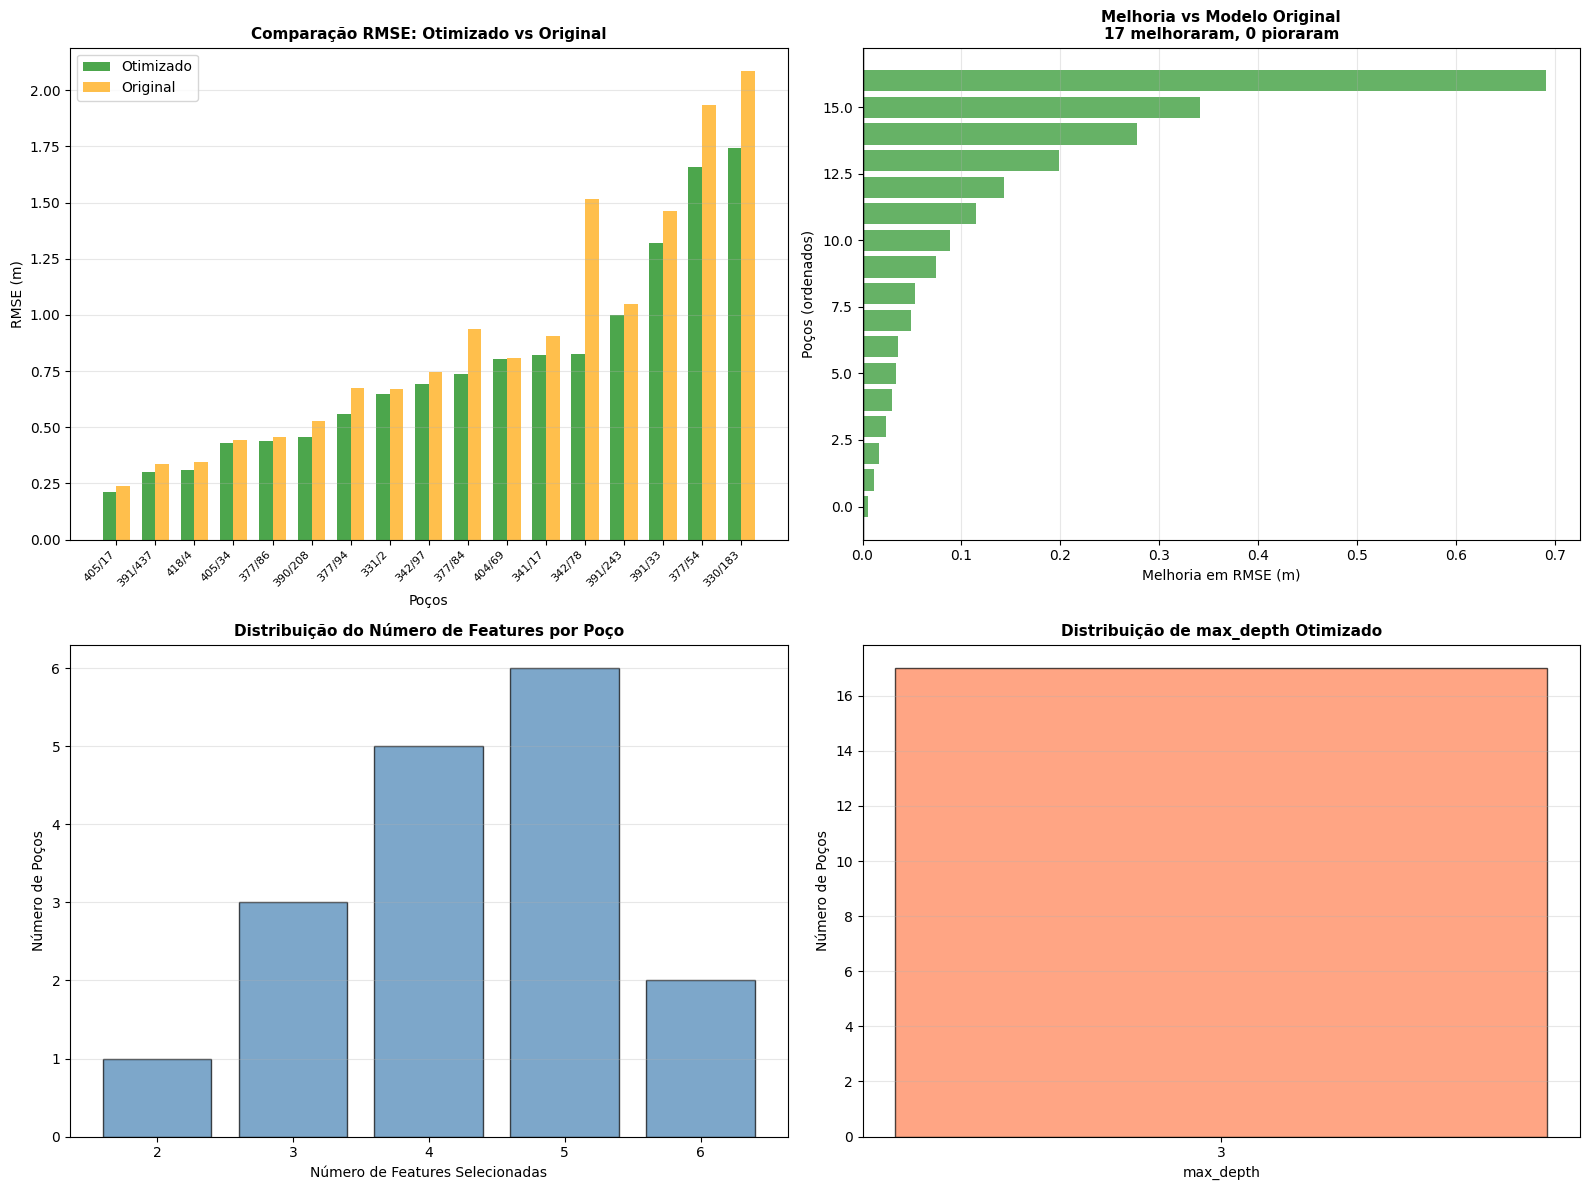

RESUMO ESTATÍSTICO DAS MELHORIAS

Melhoria em RMSE:
  Média: 0.1286 m
  Mediana: 0.0531 m
  Desvio padrão: 0.1741 m
  Min: 0.0056 m
  Max: 0.6909 m

Melhoria em MAE:
  Média: 0.0734 m
  Mediana: 0.0661 m

Melhoria em R²:
  Média: 0.8096
  Mediana: 0.1374

EXPORTAÇÃO DE RESULTADOS
✅ Resultados otimizados exportados: resultados_xgboost_otimizado_cv.csv
✅ Seleção de features exportada: feature_selection_por_poco.csv
✅ Hiperparâmetros otimizados exportados: hyperparams_otimizados_por_poco.csv
✅ Comparação otimizado vs original exportada: comparacao_otimizado_vs_original.csv

Total de poços processados: 17


In [21]:
# ============================================================================
# VISUALIZAÇÃO DAS MELHORIAS E EXPORTAÇÃO DE RESULTADOS
# ============================================================================

if 'metrics_optimized_df' in globals() and len(metrics_optimized_df) > 0:
    # Visualização comparativa
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Comparação RMSE: Otimizado vs Original
    ax1 = axes[0, 0]
    if 'metrics_original_df' in globals() and len(metrics_original_df) > 0:
        merged = metrics_optimized_df.merge(metrics_original_df, on=ID_COL, suffixes=('_opt', '_orig'))
        x_pos = np.arange(len(merged))
        width = 0.35
        
        ax1.bar(x_pos - width/2, merged['RMSE_opt'], width, label='Otimizado', color='green', alpha=0.7)
        ax1.bar(x_pos + width/2, merged['RMSE_orig'], width, label='Original', color='orange', alpha=0.7)
        ax1.set_xlabel('Poços', fontsize=10)
        ax1.set_ylabel('RMSE (m)', fontsize=10)
        ax1.set_title('Comparação RMSE: Otimizado vs Original', fontsize=11, fontweight='bold')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(merged[ID_COL], rotation=45, ha='right', fontsize=8)
        ax1.legend()
        ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Distribuição de melhorias em RMSE
    ax2 = axes[0, 1]
    if 'metrics_original_df' in globals() and len(metrics_original_df) > 0:
        improvements = merged['RMSE_improvement_vs_original']
        colors = ['green' if imp > 0 else 'red' for imp in improvements]
        ax2.barh(range(len(improvements)), improvements.sort_values(), color=colors, alpha=0.6)
        ax2.axvline(0, color='black', linestyle='-', linewidth=1)
        ax2.set_xlabel('Melhoria em RMSE (m)', fontsize=10)
        ax2.set_ylabel('Poços (ordenados)', fontsize=10)
        ax2.set_title(f'Melhoria vs Modelo Original\n{sum(improvements > 0)} melhoraram, {sum(improvements <= 0)} pioraram', 
                     fontsize=11, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='x')
    
    # 3. Número de features selecionadas por poço
    ax3 = axes[1, 0]
    if 'feature_selection_df' in globals() and len(feature_selection_df) > 0:
        n_features_counts = feature_selection_df['n_features'].value_counts().sort_index()
        ax3.bar(n_features_counts.index, n_features_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
        ax3.set_xlabel('Número de Features Selecionadas', fontsize=10)
        ax3.set_ylabel('Número de Poços', fontsize=10)
        ax3.set_title('Distribuição do Número de Features por Poço', fontsize=11, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Hiperparâmetros mais usados
    ax4 = axes[1, 1]
    if 'hyperparams_df' in globals() and len(hyperparams_df) > 0:
        # Contar valores mais comuns de max_depth
        depth_counts = hyperparams_df['max_depth'].value_counts().sort_index()
        ax4.bar(depth_counts.index.astype(str), depth_counts.values, color='coral', alpha=0.7, edgecolor='black')
        ax4.set_xlabel('max_depth', fontsize=10)
        ax4.set_ylabel('Número de Poços', fontsize=10)
        ax4.set_title('Distribuição de max_depth Otimizado', fontsize=11, fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Resumo estatístico
    print("=" * 60)
    print("RESUMO ESTATÍSTICO DAS MELHORIAS")
    print("=" * 60)
    if 'metrics_original_df' in globals() and len(metrics_original_df) > 0:
        print(f"\nMelhoria em RMSE:")
        print(f"  Média: {merged['RMSE_improvement_vs_original'].mean():.4f} m")
        print(f"  Mediana: {merged['RMSE_improvement_vs_original'].median():.4f} m")
        print(f"  Desvio padrão: {merged['RMSE_improvement_vs_original'].std():.4f} m")
        print(f"  Min: {merged['RMSE_improvement_vs_original'].min():.4f} m")
        print(f"  Max: {merged['RMSE_improvement_vs_original'].max():.4f} m")
        
        print(f"\nMelhoria em MAE:")
        print(f"  Média: {merged['MAE_improvement_vs_original'].mean():.4f} m")
        print(f"  Mediana: {merged['MAE_improvement_vs_original'].median():.4f} m")
        
        print(f"\nMelhoria em R²:")
        print(f"  Média: {merged['R2_improvement_vs_original'].mean():.4f}")
        print(f"  Mediana: {merged['R2_improvement_vs_original'].median():.4f}")
    
    # Exportar resultados
    print("\n" + "=" * 60)
    print("EXPORTAÇÃO DE RESULTADOS")
    print("=" * 60)
    
    output_optimized = "resultados_xgboost_otimizado_cv.csv"
    metrics_optimized_df.to_csv(output_optimized, index=False)
    print(f"✅ Resultados otimizados exportados: {output_optimized}")
    
    if 'feature_selection_df' in globals() and len(feature_selection_df) > 0:
        output_features = "feature_selection_por_poco.csv"
        feature_selection_df.to_csv(output_features, index=False)
        print(f"✅ Seleção de features exportada: {output_features}")
    
    if 'hyperparams_df' in globals() and len(hyperparams_df) > 0:
        output_hyperparams = "hyperparams_otimizados_por_poco.csv"
        hyperparams_df.to_csv(output_hyperparams, index=False)
        print(f"✅ Hiperparâmetros otimizados exportados: {output_hyperparams}")
    
    if 'metrics_original_df' in globals() and len(metrics_original_df) > 0:
        output_comparison = "comparacao_otimizado_vs_original.csv"
        merged.to_csv(output_comparison, index=False)
        print(f"✅ Comparação otimizado vs original exportada: {output_comparison}")
    
    print(f"\nTotal de poços processados: {len(metrics_optimized_df)}")
    
else:
    print("⚠️  metrics_optimized_df não está disponível. Execute primeiro a célula de modelação otimizada.")



In [22]:
# ============================================================================
# FUNÇÃO AUXILIAR: Obter modelo otimizado para um poço
# ============================================================================
# Esta função obtém as features e hiperparâmetros otimizados para um poço específico
# e retorna o modelo treinado usando esses parâmetros
# ============================================================================

def get_optimized_model_for_well(codigo: str, g: pd.DataFrame):
    """
    Obtém features e hiperparâmetros otimizados para um poço e retorna o modelo treinado.
    
    Returns:
        tuple: (model, best_features, best_params, use_optimized)
            - model: XGBRegressor treinado
            - best_features: lista de features selecionadas
            - best_params: dicionário com hiperparâmetros
            - use_optimized: bool indicando se usou modelo otimizado
    """
    use_optimized = False
    best_features = None
    best_params = None
    
    # Tentar obter modelo otimizado
    if 'feature_selection_df' in globals() and 'hyperparams_df' in globals():
        feature_row = feature_selection_df[feature_selection_df[ID_COL] == codigo]
        hyperparams_row = hyperparams_df[hyperparams_df[ID_COL] == codigo]
        
        if len(feature_row) > 0 and len(hyperparams_row) > 0:
            use_optimized = True
            # Extrair features selecionadas
            features_str = feature_row['features_selected'].iloc[0]
            best_features = [f.strip() for f in features_str.split(',')]
            
            # Extrair hiperparâmetros otimizados
            best_params = {
                'max_depth': int(hyperparams_row['max_depth'].iloc[0]),
                'learning_rate': float(hyperparams_row['learning_rate'].iloc[0]),
                'n_estimators': int(hyperparams_row['n_estimators'].iloc[0]),
                'subsample': float(hyperparams_row['subsample'].iloc[0]),
                'objective': 'reg:squarederror',
                'random_state': RANDOM_SEED,
                'n_jobs': N_JOBS,
            }
    
    # Se não houver modelo otimizado, usar padrão
    if not use_optimized:
        best_features = [c for c in XREG_COLS if c in g.columns]
        best_params = XGB_PARAMS.copy()
    
    # Treinar modelo
    X_all = g[best_features].to_numpy()
    y_all = g[TARGET_COL].to_numpy()
    
    model = XGBRegressor(**best_params)
    model.fit(X_all, y_all)
    
    return model, best_features, best_params, use_optimized

print("✅ Função auxiliar get_optimized_model_for_well() definida com sucesso!")



✅ Função auxiliar get_optimized_model_for_well() definida com sucesso!


In [ ]:
# ============================================================================
# VISUALIZAÇÃO INTERATIVA POR POÇO (USANDO MODELO OTIMIZADO COM CV)
# ============================================================================
# Esta célula substitui a visualização antiga e usa automaticamente o modelo
# otimizado (com features selecionadas e hiperparâmetros ajustados) se disponível
# ============================================================================

try:
    from ipywidgets import interact, widgets
    has_widgets = True
except Exception:
    has_widgets = False
    print("Para filtro interativo, instale ipywidgets: %pip install ipywidgets")

codes = sorted(df[ID_COL].dropna().unique().tolist())

# Priorizar modelo otimizado se disponível
default_code = (
    metrics_optimized_df[ID_COL].iloc[0]
    if 'metrics_optimized_df' in globals() and len(metrics_optimized_df) > 0
    else (metrics_df[ID_COL].iloc[0]
          if 'metrics_df' in globals() and len(metrics_df) > 0
          else (codes[0] if len(codes) > 0 else None))
)


def plot_for_codigo_optimized(codigo):
    """Visualização usando modelo otimizado com CV."""
    if codigo is None:
        return

    g = df[df[ID_COL] == codigo].sort_values(DATE_COL).reset_index(drop=True)
    if len(g) < MIN_SERIES_LENGTH:
        print(f"Poço {codigo}: série curta ({len(g)} observações).")
        return

    # Obter modelo otimizado
    model_full, best_features, best_params, use_optimized = get_optimized_model_for_well(codigo, g)
    
    if not best_features:
        print(f"Poço {codigo}: não há variáveis exógenas disponíveis.")
        return

    if g[best_features + [TARGET_COL]].isna().any().any():
        print(f"Poço {codigo}: existem NAs nas features/target mesmo após limpeza.")
        return

    train_df, test_df = temporal_split(g, TEST_FRACTION)

    y_train = train_df[TARGET_COL].to_numpy()
    y_test = test_df[TARGET_COL].to_numpy()
    X_train = train_df[best_features].to_numpy()
    X_test = test_df[best_features].to_numpy()

    # Treinar modelo no conjunto de treino (usando parâmetros otimizados)
    model = XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Baseline de persistência
    y_pred_persist = np.r_[y_train[-1], y_test[:-1]]

    # Métricas
    rmse_val = rmse(y_test, y_pred)
    mae_val = float(mean_absolute_error(y_test, y_pred))
    mape_val = mape(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)
    rmse_base_val = rmse(y_test, y_pred_persist)

    # Figura com 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Série temporal
    ax1 = axes[0]
    model_label = "Forecast (XGBoost Otimizado - CV)" if use_optimized else "Forecast (XGBoost)"
    ax1.plot(g[DATE_COL], g[TARGET_COL], label="Observado", color="C0", linewidth=1.5, marker='o', markersize=3)
    ax1.axvline(test_df[DATE_COL].iloc[0], color="k", linestyle="--", alpha=0.6, linewidth=2, label="Split Train/Test")
    ax1.plot(test_df[DATE_COL], y_pred, label=model_label, color="C3", linewidth=2, marker='s', markersize=4)
    ax1.plot(test_df[DATE_COL], y_pred_persist, label="Baseline (Persistência)", color="C2", alpha=0.7,
             linewidth=1.5, linestyle='--')
    title_suffix = " (Otimizado com CV)" if use_optimized else ""
    ax1.set_title(
        f"Poço {codigo} - XGBoost{title_suffix}\n"
        f"RMSE={rmse_val:.3f} | MAE={mae_val:.3f} | MAPE={mape_val:.2f}% | R²={r2_val:.3f}\n"
        f"Baseline RMSE={rmse_base_val:.3f} | Ganho RMSE={rmse_base_val - rmse_val:.3f}",
        fontsize=11, fontweight='bold'
    )
    ax1.invert_yaxis()
    ax1.set_ylabel("Profundidade (m)", fontsize=10)
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Resíduos
    ax2 = axes[1]
    residuals = y_test - y_pred
    ax2.plot(test_df[DATE_COL], residuals, 'o-', color='C4', markersize=4, linewidth=1)
    ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax2.set_title("Resíduos (Observado - Previsto)", fontsize=10, fontweight='bold')
    ax2.set_xlabel("Data", fontsize=10)
    ax2.set_ylabel("Resíduo (m)", fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nEstatísticas dos resíduos para poço {codigo}:")
    print(f"  Média: {np.mean(residuals):.4f} m")
    print(f"  Desvio padrão: {np.std(residuals):.4f} m")
    print(f"  Min: {np.min(residuals):.4f} m")
    print(f"  Max: {np.max(residuals):.4f} m")
    
    if use_optimized:
        print(f"\n📊 Modelo otimizado usado:")
        print(f"   Features: {best_features}")
        print(f"   max_depth={best_params['max_depth']}, lr={best_params['learning_rate']:.3f}, "
              f"n_est={best_params['n_estimators']}, subsample={best_params['subsample']:.2f}")


if has_widgets and default_code is not None and len(codes) > 0:
    interact(
        plot_for_codigo_optimized,
        codigo=widgets.Dropdown(options=codes, value=default_code, description='poço')
    )
elif default_code is not None:
    plot_for_codigo_optimized(default_code)



interactive(children=(Dropdown(description='poço', index=14, options=('330/183', '331/2', '341/17', '342/78', …

In [24]:
# Loop de modelação por poço com XGBoost

results = []
failed_wells = []
feature_importances = []  # para guardar importância das variáveis por poço

for codigo, g in tqdm(df.groupby(ID_COL), total=df[ID_COL].nunique()):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    if len(g) < MIN_SERIES_LENGTH:
        continue

    # Selecionar variáveis exógenas disponíveis para este poço
    feature_cols = [c for c in XREG_COLS if c in g.columns]
    if not feature_cols:
        # Se não houver variáveis de entrada, ignorar poço
        continue

    # Garantir que não existem NAs
    if g[feature_cols + [TARGET_COL]].isna().any().any():
        continue

    # Split temporal
    train_df, test_df = temporal_split(g, TEST_FRACTION)

    y_train = train_df[TARGET_COL].to_numpy()
    y_test = test_df[TARGET_COL].to_numpy()

    # Se a parte de teste for muito pequena, ignorar
    if len(y_test) < 2:
        continue

    X_train = train_df[feature_cols].to_numpy()
    X_test = test_df[feature_cols].to_numpy()

    try:
        model, y_pred = fit_predict_xgboost(train_df, test_df, feature_cols)

        # Baseline de persistência: y_t = y_{t-1}
        y_pred_persist = np.r_[y_train[-1], y_test[:-1]]

        # Métricas do modelo
        rmse_model = rmse(y_test, y_pred)
        mae_model = float(mean_absolute_error(y_test, y_pred))
        mape_model = mape(y_test, y_pred)
        r2_model = r2_score(y_test, y_pred)

        # Métricas do baseline
        rmse_base = rmse(y_test, y_pred_persist)
        mae_base = float(mean_absolute_error(y_test, y_pred_persist))
        mape_base = mape(y_test, y_pred_persist)
        r2_base = r2_score(y_test, y_pred_persist)

        params = model.get_params()

        # Guardar métricas agregadas por poço
        res = {
            ID_COL: codigo,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "n_vars": len(feature_cols),
            "RMSE": rmse_model,
            "MAE": mae_model,
            "MAPE": mape_model,
            "R2": r2_model,
            "RMSE_baseline": rmse_base,
            "MAE_baseline": mae_base,
            "MAPE_baseline": mape_base,
            "R2_baseline": r2_base,
            "RMSE_gain": rmse_base - rmse_model,
            "MAE_gain": mae_base - mae_model,
            "MAPE_gain": mape_base - mape_model,
            "R2_gain": r2_model - r2_base,
            "model_type": "XGBoost",
            "n_estimators": params.get("n_estimators"),
            "max_depth": params.get("max_depth"),
            "learning_rate": params.get("learning_rate"),
        }
        results.append(res)

        # Guardar feature importances para este poço (se disponíveis)
        importances = getattr(model, "feature_importances_", None)
        if importances is not None:
            total_imp = float(importances.sum()) or 1.0
            for feat, imp in zip(feature_cols, importances):
                feature_importances.append(
                    {
                        ID_COL: codigo,
                        "feature": feat,
                        "importance": float(imp),
                        "importance_norm": float(imp) / total_imp,
                    }
                )

    except Exception as e:
        failed_wells.append((codigo, str(e)))
        continue

metrics_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

if feature_importances:
    feature_importance_df = pd.DataFrame(feature_importances)
else:
    feature_importance_df = pd.DataFrame(columns=[ID_COL, "feature", "importance", "importance_norm"])

print("=" * 60)
print("RESUMO DOS RESULTADOS DO MODELO XGBOOST")
print("=" * 60)
print(f"Poços modelados: {len(metrics_df)}")
print(f"Poços com falha: {len(failed_wells)}")
if failed_wells:
    print("\nPoços com falha (primeiros 5):")
    for codigo, error in failed_wells[:5]:
        print(f"  - {codigo}: {error[:120]}")

print("\n" + "=" * 60)
print("ESTATÍSTICAS DAS MÉTRICAS (média por poço)")
print("=" * 60)
print(f"RMSE médio: {metrics_df['RMSE'].mean():.4f} ± {metrics_df['RMSE'].std():.4f}")
print(f"MAE médio: {metrics_df['MAE'].mean():.4f} ± {metrics_df['MAE'].std():.4f}")
print(f"MAPE médio: {metrics_df['MAPE'].mean():.2f}% ± {metrics_df['MAPE'].std():.2f}%")
print(f"R² médio: {metrics_df['R2'].mean():.4f} ± {metrics_df['R2'].std():.4f}")

print("\n" + "=" * 60)
print("COMPARAÇÃO COM BASELINE (PERSISTÊNCIA)")
print("=" * 60)
print(f"Ganho médio em RMSE: {metrics_df['RMSE_gain'].mean():.4f}")
print(f"  - Poços com ganho: {(metrics_df['RMSE_gain'] > 0).sum()} / {len(metrics_df)}")
print(f"Ganho médio em MAE: {metrics_df['MAE_gain'].mean():.4f}")
print(f"Ganho médio em MAPE: {metrics_df['MAPE_gain'].mean():.2f}%")
print(f"Ganho médio em R²: {metrics_df['R2_gain'].mean():.4f}")

print("\n" + "=" * 60)
print("TOP 10 MELHORES MODELOS (menor RMSE)")
print("=" * 60)
if len(metrics_df) > 0:
    display(metrics_df.head(10)[[ID_COL, 'n_train', 'n_test', 'n_vars', 'RMSE', 'MAE', 'MAPE', 'R2',
                                 'RMSE_gain', 'model_type', 'n_estimators', 'max_depth']])

print("\n" + "=" * 60)
print("TOP 10 PIORES MODELOS (maior RMSE)")
print("=" * 60)
if len(metrics_df) > 0:
    display(metrics_df.tail(10)[[ID_COL, 'n_train', 'n_test', 'n_vars', 'RMSE', 'MAE', 'MAPE', 'R2',
                                 'RMSE_gain', 'model_type', 'n_estimators', 'max_depth']])

metrics_df


  0%|          | 0/17 [00:00<?, ?it/s]

RESUMO DOS RESULTADOS DO MODELO XGBOOST
Poços modelados: 17
Poços com falha: 0

ESTATÍSTICAS DAS MÉTRICAS (média por poço)
RMSE médio: 0.8903 ± 0.5556
MAE médio: 0.6956 ± 0.4067
MAPE médio: 21.71% ± 26.29%
R² médio: -2.0440 ± 7.2680

COMPARAÇÃO COM BASELINE (PERSISTÊNCIA)
Ganho médio em RMSE: -0.0707
  - Poços com ganho: 8 / 17
Ganho médio em MAE: -0.0994
Ganho médio em MAPE: -5.81%
Ganho médio em R²: -2.3094

TOP 10 MELHORES MODELOS (menor RMSE)


,codigo,n_train,n_test,n_vars,RMSE,MAE,MAPE,R2,RMSE_gain,model_type,n_estimators,max_depth
0,405/17,168,42,6,0.239519,0.172482,15.926943,0.604066,0.030472,XGBoost,500,4
1,391/437,134,33,6,0.337359,0.281623,2.136930,0.739016,0.126502,XGBoost,500,4
2,418/4,145,36,6,0.342935,0.269985,12.858856,0.267983,-0.085603,XGBoost,500,4
3,405/34,64,16,6,0.442284,0.360193,19.743824,0.791808,0.580696,XGBoost,500,4
4,377/86,157,39,6,0.454591,0.350698,7.984912,0.867712,0.507718,XGBoost,500,4
5,390/208,61,15,6,0.529672,0.432987,7.604061,0.448934,0.050500,XGBoost,500,4
6,331/2,65,16,6,0.671836,0.613655,11.461593,0.265725,0.042697,XGBoost,500,4
7,377/94,176,44,6,0.673527,0.541126,22.594013,-4.364906,-0.457547,XGBoost,500,4
8,342/97,46,12,6,0.744526,0.614755,9.584863,-2.864491,-0.241758,XGBoost,500,4
9,404/69,110,28,6,0.808279,0.647140,15.091120,0.602033,0.283821,XGBoost,500,4



TOP 10 PIORES MODELOS (maior RMSE)


,codigo,n_train,n_test,n_vars,RMSE,MAE,MAPE,R2,RMSE_gain,model_type,n_estimators,max_depth
7,377/94,176,44,6,0.673527,0.541126,22.594013,-4.364906,-0.457547,XGBoost,500,4
8,342/97,46,12,6,0.744526,0.614755,9.584863,-2.864491,-0.241758,XGBoost,500,4
9,404/69,110,28,6,0.808279,0.647140,15.091120,0.602033,0.283821,XGBoost,500,4
10,341/17,154,39,6,0.907328,0.749309,10.278018,-0.196633,-0.294655,XGBoost,500,4
11,377/84,39,10,6,0.937842,0.719673,9.812356,0.878773,1.787748,XGBoost,500,4
12,391/243,82,21,6,1.046560,0.975724,41.178805,-2.039577,-0.656480,XGBoost,500,4
13,391/33,178,44,6,1.461122,1.266973,13.785082,-1.629624,-0.845212,XGBoost,500,4
14,342/78,74,19,6,1.516711,0.864987,31.548831,-0.002970,-0.358411,XGBoost,500,4
15,377/54,60,15,6,1.936352,1.423742,20.549348,0.515906,-0.019814,XGBoost,500,4
16,330/183,171,43,6,2.085403,1.540208,116.891632,-29.632031,-1.651944,XGBoost,500,4


,codigo,n_train,n_test,n_vars,RMSE,MAE,MAPE,R2,RMSE_baseline,MAE_baseline,MAPE_baseline,R2_baseline,RMSE_gain,MAE_gain,MAPE_gain,R2_gain,model_type,n_estimators,max_depth,learning_rate
0,405/17,168,42,6,0.239519,0.172482,15.926943,0.604066,0.269991,0.196190,19.958989,0.496913,0.030472,0.023708,4.032046,0.107153,XGBoost,500,4,0.05
1,391/437,134,33,6,0.337359,0.281623,2.136930,0.739016,0.463861,0.349394,2.602454,0.506594,0.126502,0.067771,0.465525,0.232422,XGBoost,500,4,0.05
2,418/4,145,36,6,0.342935,0.269985,12.858856,0.267983,0.257331,0.214167,11.010095,0.587823,-0.085603,-0.055818,-1.848761,-0.319840,XGBoost,500,4,0.05
3,405/34,64,16,6,0.442284,0.360193,19.743824,0.791808,1.022980,0.653750,34.621777,-0.113770,0.580696,0.293557,14.877952,0.905578,XGBoost,500,4,0.05
4,377/86,157,39,6,0.454591,0.350698,7.984912,0.867712,0.962310,0.720769,14.741313,0.407198,0.507718,0.370071,6.756401,0.460513,XGBoost,500,4,0.05
5,390/208,61,15,6,0.529672,0.432987,7.604061,0.448934,0.580172,0.474667,8.461703,0.338845,0.050500,0.041679,0.857642,0.110088,XGBoost,500,4,0.05
6,331/2,65,16,6,0.671836,0.613655,11.461593,0.265725,0.714532,0.538125,10.577223,0.169431,0.042697,-0.075530,-0.884370,0.096295,XGBoost,500,4,0.05
7,377/94,176,44,6,0.673527,0.541126,22.594013,-4.364906,0.215981,0.138864,6.196014,0.448327,-0.457547,-0.402262,-16.398000,-4.813232,XGBoost,500,4,0.05
8,342/97,46,12,6,0.744526,0.614755,9.584863,-2.864491,0.502767,0.409167,6.557797,-0.762249,-0.241758,-0.205588,-3.027065,-2.102242,XGBoost,500,4,0.05
9,404/69,110,28,6,0.808279,0.647140,15.091120,0.602033,1.092100,0.837500,17.940966,0.273477,0.283821,0.190360,2.849846,0.328555,XGBoost,500,4,0.05


In [25]:
# Feature importance por poço (XGBoost)

if 'feature_importance_df' in globals() and len(feature_importance_df) > 0:
    print("=" * 60)
    print("FEATURE IMPORTANCE - XGBOOST (por poço)")
    print("=" * 60)

    # Importância média normalizada por variável (média sobre poços)
    mean_imp = (
        feature_importance_df
        .groupby("feature")["importance_norm"]
        .mean()
        .sort_values(ascending=False)
    )
    print("\nImportância média normalizada por variável (média sobre poços):")
    display(mean_imp.to_frame("importance_mean_norm"))

    # Top 3 variáveis por poço
    top_per_well = (
        feature_importance_df
        .sort_values([ID_COL, "importance_norm"], ascending=[True, False])
        .groupby(ID_COL)
        .head(3)
        .reset_index(drop=True)
    )
    print("\nTop 3 variáveis por poço (importância normalizada):")
    display(top_per_well)
else:
    print("feature_importance_df não está definido ou está vazio. Execute primeiro a célula de modelação por poço.")



FEATURE IMPORTANCE - XGBOOST (por poço)

Importância média normalizada por variável (média sobre poços):


,importance_mean_norm
feature,
eto_lag2,0.228051
eto_lag1,0.208716
caudal_lag1,0.193933
caudal_lag2,0.148930
rr_lag1,0.118141
rr_lag2,0.102229



Top 3 variáveis por poço (importância normalizada):


,codigo,feature,importance,importance_norm
0,330/183,caudal_lag1,0.202606,0.202606
1,330/183,eto_lag1,0.194153,0.194153
2,330/183,caudal_lag2,0.170204,0.170204
3,331/2,caudal_lag1,0.415883,0.415883
4,331/2,caudal_lag2,0.219783,0.219783
5,331/2,eto_lag2,0.124180,0.124180
6,341/17,caudal_lag1,0.303533,0.303533
7,341/17,caudal_lag2,0.249068,0.249068
8,341/17,eto_lag2,0.225536,0.225536
9,342/78,eto_lag1,0.225458,0.225458


In [26]:
# ============================================================================
# PREVISÕES FUTURAS COM MODELO OTIMIZADO (CV)
# ============================================================================
# Gera previsões futuras usando o modelo otimizado (features selecionadas
# e hiperparâmetros ajustados) para cada poço
# ============================================================================

# Número de meses a prever (podes alterar para 6, 12, etc.)
FORECAST_HORIZON = 12  # meses

future_forecasts_optimized = []

for codigo, g in tqdm(df.groupby(ID_COL), total=df[ID_COL].nunique(), desc="Gerando previsões"):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    if len(g) < MIN_SERIES_LENGTH:
        continue

    # Obter modelo otimizado para este poço
    model_full, best_features, best_params, use_optimized = get_optimized_model_for_well(codigo, g)
    
    if not best_features:
        continue

    if g[best_features + [TARGET_COL]].isna().any().any():
        continue

    # Treinar modelo XGBoost em TODA a série histórica desse poço (com parâmetros otimizados)
    X_all = g[best_features].to_numpy()
    y_all = g[TARGET_COL].to_numpy()

    model = XGBRegressor(**best_params)
    model.fit(X_all, y_all)

    # Construir datas futuras (mesmo esquema de datas mensais)
    last_date = g[DATE_COL].iloc[-1]
    # Usa início de mês (freq="MS") para ser consistente com o reindex mensal
    future_dates = pd.date_range(
        last_date.to_period("M").to_timestamp(),
        periods=FORECAST_HORIZON + 1,
        freq="MS",
    )[1:]  # remover a própria last_date

    # CENÁRIO PARA AS FEATURES FUTURAS:
    # usamos o padrão dos últimos FORECAST_HORIZON meses de variáveis exógenas,
    # assumindo que o próximo ano terá um comportamento semelhante.
    hist_feats = g[best_features].tail(FORECAST_HORIZON).to_numpy()
    if len(hist_feats) < FORECAST_HORIZON:
        # se a série for mais curta que o horizonte, repetimos o último valor
        last_row = hist_feats[-1:].copy()
        extra = np.repeat(last_row, FORECAST_HORIZON - len(hist_feats), axis=0)
        X_future = np.vstack([hist_feats, extra])
    else:
        X_future = hist_feats.copy()

    y_future = model.predict(X_future)

    for h, (dt, y_hat) in enumerate(zip(future_dates, y_future), start=1):
        future_forecasts_optimized.append(
            {
                ID_COL: codigo,
                DATE_COL: dt,
                "horizon_months": h,
                "y_hat_xgb_optimized": float(y_hat),
                "used_optimized": use_optimized,
            }
        )

forecast_optimized_df = pd.DataFrame(future_forecasts_optimized)

print("=" * 60)
print("PREVISÕES FUTURAS (XGBoost OTIMIZADO com CV) POR POÇO")
print("=" * 60)
print(f"Poços com previsão gerada: {forecast_optimized_df[ID_COL].nunique()}")
print(f"Total de pontos de previsão: {len(forecast_optimized_df)}")
print(f"Poços usando modelo otimizado: {forecast_optimized_df['used_optimized'].sum()}")
print("\nExemplo de previsões (primeiras linhas):")
display(forecast_optimized_df.head(20))

# Exportar previsões
output_forecast_csv = "previsoes_xgboost_otimizado_cv_12m.csv"
forecast_optimized_df.to_csv(output_forecast_csv, index=False)
print(f"\n✅ Previsões futuras (otimizadas) exportadas para: {output_forecast_csv}")
print("Para obter apenas 6 meses, podes filtrar: forecast_optimized_df[forecast_optimized_df['horizon_months'] <= 6]")



Gerando previsões:   0%|          | 0/17 [00:00<?, ?it/s]

PREVISÕES FUTURAS (XGBoost OTIMIZADO com CV) POR POÇO
Poços com previsão gerada: 17
Total de pontos de previsão: 204
Poços usando modelo otimizado: 204

Exemplo de previsões (primeiras linhas):


,codigo,ym,horizon_months,y_hat_xgb_optimized,used_optimized
0,330/183,2024-07-01,1,3.041766,True
1,330/183,2024-08-01,2,3.072352,True
2,330/183,2024-09-01,3,4.287115,True
3,330/183,2024-10-01,4,1.992135,True
4,330/183,2024-11-01,5,1.664535,True
5,330/183,2024-12-01,6,1.338975,True
6,330/183,2025-01-01,7,1.248138,True
7,330/183,2025-02-01,8,1.107114,True
8,330/183,2025-03-01,9,1.237589,True
9,330/183,2025-04-01,10,1.233354,True



✅ Previsões futuras (otimizadas) exportadas para: previsoes_xgboost_otimizado_cv_12m.csv
Para obter apenas 6 meses, podes filtrar: forecast_optimized_df[forecast_optimized_df['horizon_months'] <= 6]


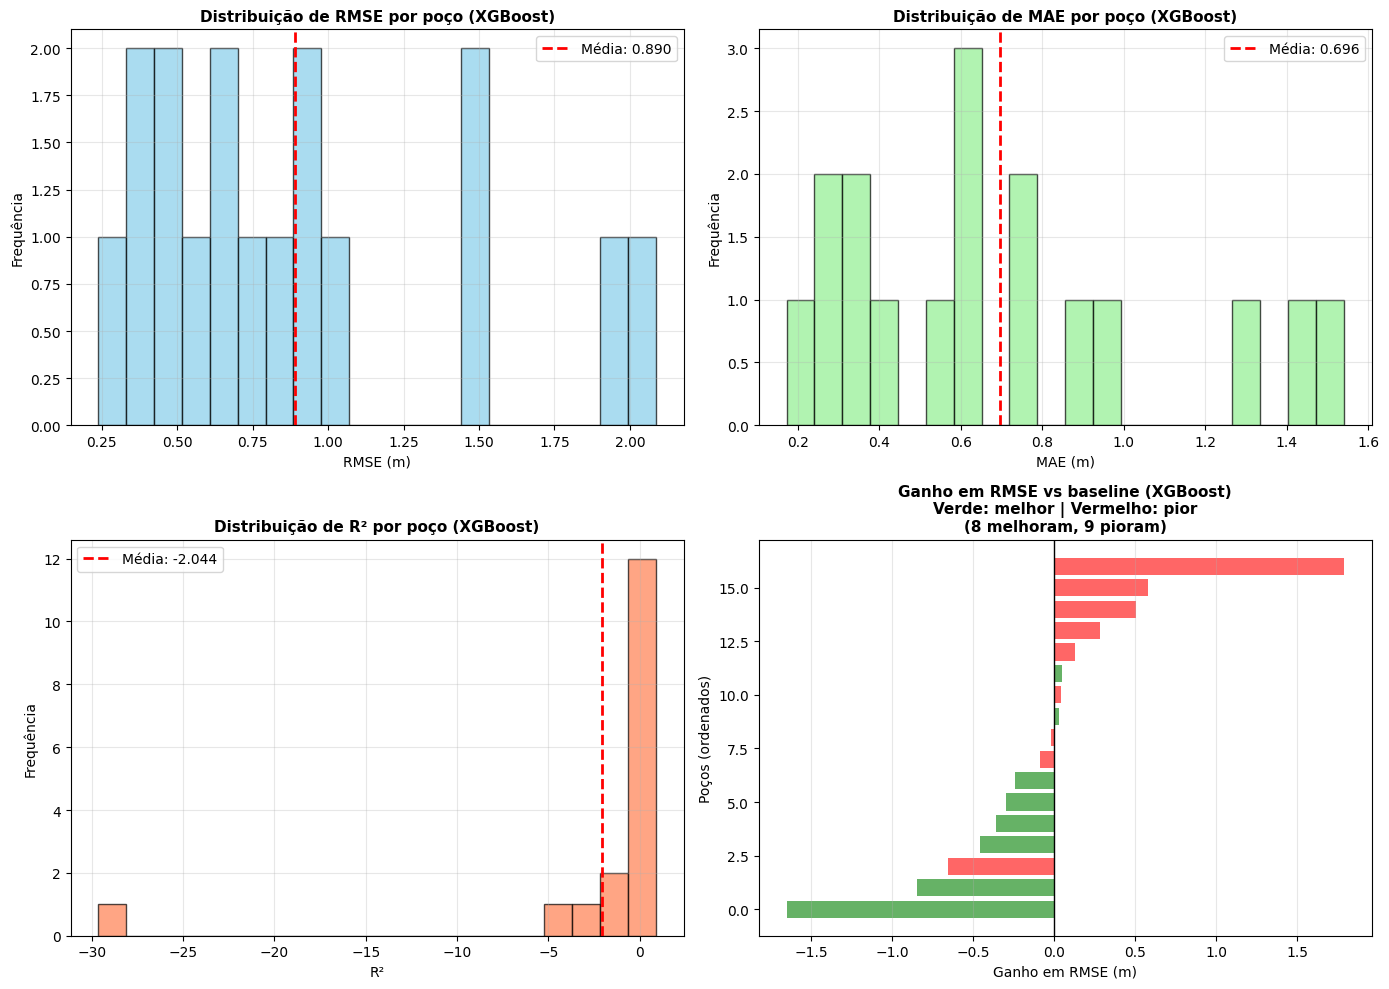


Resumo: 8 poços (47.1%) têm melhor RMSE que o baseline
        9 poços (52.9%) têm pior RMSE que o baseline


In [27]:
# Distribuição de métricas (RMSE, MAE, R², ganho em RMSE)

if 'metrics_df' in globals() and len(metrics_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # RMSE
    ax1 = axes[0, 0]
    ax1.hist(metrics_df['RMSE'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    ax1.axvline(metrics_df['RMSE'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Média: {metrics_df["RMSE"].mean():.3f}')
    ax1.set_xlabel('RMSE (m)', fontsize=10)
    ax1.set_ylabel('Frequência', fontsize=10)
    ax1.set_title('Distribuição de RMSE por poço (XGBoost)', fontsize=11, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # MAE
    ax2 = axes[0, 1]
    ax2.hist(metrics_df['MAE'], bins=20, edgecolor='black', alpha=0.7, color='lightgreen')
    ax2.axvline(metrics_df['MAE'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Média: {metrics_df["MAE"].mean():.3f}')
    ax2.set_xlabel('MAE (m)', fontsize=10)
    ax2.set_ylabel('Frequência', fontsize=10)
    ax2.set_title('Distribuição de MAE por poço (XGBoost)', fontsize=11, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # R²
    ax3 = axes[1, 0]
    ax3.hist(metrics_df['R2'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax3.axvline(metrics_df['R2'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Média: {metrics_df["R2"].mean():.3f}')
    ax3.set_xlabel('R²', fontsize=10)
    ax3.set_ylabel('Frequência', fontsize=10)
    ax3.set_title('Distribuição de R² por poço (XGBoost)', fontsize=11, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Ganho em RMSE vs baseline
    ax4 = axes[1, 1]
    gain_positive = (metrics_df['RMSE_gain'] > 0).sum()
    gain_negative = (metrics_df['RMSE_gain'] <= 0).sum()
    colors = ['green' if g > 0 else 'red' for g in metrics_df['RMSE_gain']]
    ax4.barh(range(len(metrics_df)), metrics_df['RMSE_gain'].sort_values(), color=colors, alpha=0.6)
    ax4.axvline(0, color='black', linestyle='-', linewidth=1)
    ax4.set_xlabel('Ganho em RMSE (m)', fontsize=10)
    ax4.set_ylabel('Poços (ordenados)', fontsize=10)
    ax4.set_title(
        f'Ganho em RMSE vs baseline (XGBoost)\n'
        f'Verde: melhor | Vermelho: pior\n({gain_positive} melhoram, {gain_negative} pioram)',
        fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print(f"\nResumo: {gain_positive} poços ({100*gain_positive/len(metrics_df):.1f}%) têm melhor RMSE que o baseline")
    print(f"        {gain_negative} poços ({100*gain_negative/len(metrics_df):.1f}%) têm pior RMSE que o baseline")
else:
    print("metrics_df não está definido ou está vazio. Execute primeiro a célula de modelação por poço.")



In [28]:
# Exportar resultados para CSV

if 'metrics_df' in globals() and len(metrics_df) > 0:
    output_csv = "resultados_xgboost_por_poco.csv"
    metrics_df.to_csv(output_csv, index=False)
    print(f"Resultados exportados para: {output_csv}")
    print(f"Total de poços: {len(metrics_df)}")
else:
    print("metrics_df não está definido ou está vazio. Execute primeiro a célula de modelação por poço.")



Resultados exportados para: resultados_xgboost_por_poco.csv
Total de poços: 17


In [29]:
# Visualização interativa por poço (XGBoost)

try:
    from ipywidgets import interact, widgets
    has_widgets = True
except Exception:
    has_widgets = False
    print("Para filtro interativo, instale ipywidgets: %pip install ipywidgets")

codes = sorted(df[ID_COL].dropna().unique().tolist())

default_code = (
    metrics_df[ID_COL].iloc[0]
    if 'metrics_df' in globals() and len(metrics_df) > 0
    else (codes[0] if len(codes) > 0 else None)
)


def plot_for_codigo(codigo):
    if codigo is None:
        return

    g = df[df[ID_COL] == codigo].sort_values(DATE_COL).reset_index(drop=True)
    if len(g) < MIN_SERIES_LENGTH:
        print(f"Poço {codigo}: série curta ({len(g)} observações).")
        return

    feature_cols = [c for c in XREG_COLS if c in g.columns]
    if not feature_cols:
        print(f"Poço {codigo}: não há variáveis exógenas disponíveis.")
        return

    if g[feature_cols + [TARGET_COL]].isna().any().any():
        print(f"Poço {codigo}: existem NAs nas features/target mesmo após limpeza.")
        return

    train_df, test_df = temporal_split(g, TEST_FRACTION)

    y_train = train_df[TARGET_COL].to_numpy()
    y_test = test_df[TARGET_COL].to_numpy()
    X_train = train_df[feature_cols].to_numpy()
    X_test = test_df[feature_cols].to_numpy()

    model, y_pred = fit_predict_xgboost(train_df, test_df, feature_cols)

    # Baseline de persistência
    y_pred_persist = np.r_[y_train[-1], y_test[:-1]]

    # Métricas
    rmse_val = rmse(y_test, y_pred)
    mae_val = float(mean_absolute_error(y_test, y_pred))
    mape_val = mape(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)
    rmse_base_val = rmse(y_test, y_pred_persist)

    # Figura com 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Série temporal
    ax1 = axes[0]
    ax1.plot(g[DATE_COL], g[TARGET_COL], label="Observado", color="C0", linewidth=1.5, marker='o', markersize=3)
    ax1.axvline(test_df[DATE_COL].iloc[0], color="k", linestyle="--", alpha=0.6, linewidth=2, label="Split Train/Test")
    ax1.plot(test_df[DATE_COL], y_pred, label="Forecast (XGBoost)", color="C3", linewidth=2, marker='s', markersize=4)
    ax1.plot(test_df[DATE_COL], y_pred_persist, label="Baseline (Persistência)", color="C2", alpha=0.7,
             linewidth=1.5, linestyle='--')
    ax1.set_title(
        f"Poço {codigo} - XGBoost\n"
        f"RMSE={rmse_val:.3f} | MAE={mae_val:.3f} | MAPE={mape_val:.2f}% | R²={r2_val:.3f}\n"
        f"Baseline RMSE={rmse_base_val:.3f} | Ganho RMSE={rmse_base_val - rmse_val:.3f}",
        fontsize=11, fontweight='bold'
    )
    ax1.invert_yaxis()
    ax1.set_ylabel("Profundidade (m)", fontsize=10)
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Resíduos
    ax2 = axes[1]
    residuals = y_test - y_pred
    ax2.plot(test_df[DATE_COL], residuals, 'o-', color='C4', markersize=4, linewidth=1)
    ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax2.set_title("Resíduos (Observado - Previsto)", fontsize=10, fontweight='bold')
    ax2.set_xlabel("Data", fontsize=10)
    ax2.set_ylabel("Resíduo (m)", fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nEstatísticas dos resíduos para poço {codigo}:")
    print(f"  Média: {np.mean(residuals):.4f} m")
    print(f"  Desvio padrão: {np.std(residuals):.4f} m")
    print(f"  Min: {np.min(residuals):.4f} m")
    print(f"  Max: {np.max(residuals):.4f} m")


if has_widgets and default_code is not None and len(codes) > 0:
    interact(
        plot_for_codigo,
        codigo=widgets.Dropdown(options=codes, value=default_code, description='poço')
    )
elif default_code is not None:
    plot_for_codigo(default_code)



interactive(children=(Dropdown(description='poço', index=14, options=('330/183', '331/2', '341/17', '342/78', …

In [ ]:
# Comparação direta ARIMAX vs XGBoost para o mesmo poço

try:
    from pmdarima.arima import auto_arima
    has_pmdarima = True
except Exception:
    has_pmdarima = False
    print("Para comparar com ARIMAX, instale pmdarima: %pip install pmdarima")


def fit_predict_arimax_for_comparison(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = TARGET_COL,
    m: int = SEASONAL_PERIOD,
):
    """Versão simplificada do ARIMAX, usada apenas para comparação com XGBoost."""
    if not has_pmdarima:
        raise ImportError("pmdarima não está disponível no ambiente.")

    y_train = train_df[target_col].to_numpy()
    X_train = train_df[feature_cols].to_numpy()
    X_test = test_df[feature_cols].to_numpy()

    model = auto_arima(
        y=y_train,
        exogenous=X_train,
        seasonal=True,
        m=m,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False,
        with_intercept=True,
        max_p=5,
        max_d=2,
        max_q=5,
        max_P=2,
        max_D=1,
        max_Q=2,
        start_p=0,
        start_q=0,
        start_P=0,
        start_Q=0,
        d=1,
        D=1,
        test="adf",
        information_criterion="aic",
        n_jobs=-1,
    )
    y_pred = model.predict(n_periods=len(X_test), exogenous=X_test)
    return model, np.asarray(y_pred)


def compare_arimax_xgboost(codigo: str):
    if not has_pmdarima:
        print("pmdarima não está instalado, não é possível ajustar o ARIMAX.")
        return

    g = df[df[ID_COL] == codigo].sort_values(DATE_COL).reset_index(drop=True)
    if len(g) < MIN_SERIES_LENGTH:
        print(f"Poço {codigo}: série curta ({len(g)} observações).")
        return

    feature_cols = [c for c in XREG_COLS if c in g.columns]
    if not feature_cols:
        print(f"Poço {codigo}: não há variáveis exógenas disponíveis.")
        return

    if g[feature_cols + [TARGET_COL]].isna().any().any():
        print(f"Poço {codigo}: existem NAs nas features/target mesmo após limpeza.")
        return

    train_df, test_df = temporal_split(g, TEST_FRACTION)

    y_train = train_df[TARGET_COL].to_numpy()
    y_test = test_df[TARGET_COL].to_numpy()

    # ARIMAX
    arima_model, y_pred_arima = fit_predict_arimax_for_comparison(train_df, test_df, feature_cols)
    y_pred_persist = np.r_[y_train[-1], y_test[:-1]]

    rmse_arima = rmse(y_test, y_pred_arima)
    mae_arima = float(mean_absolute_error(y_test, y_pred_arima))
    mape_arima = mape(y_test, y_pred_arima)
    r2_arima = r2_score(y_test, y_pred_arima)
    rmse_base = rmse(y_test, y_pred_persist)

    # XGBoost
    xgb_model, y_pred_xgb = fit_predict_xgboost(train_df, test_df, feature_cols)

    rmse_xgb = rmse(y_test, y_pred_xgb)
    mae_xgb = float(mean_absolute_error(y_test, y_pred_xgb))
    mape_xgb = mape(y_test, y_pred_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)

    # Figura com 2 colunas: ARIMAX vs XGBoost
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex="col")

    # Série temporal ARIMAX
    ax1 = axes[0, 0]
    ax1.plot(g[DATE_COL], g[TARGET_COL], label="Observado", color="C0", linewidth=1.5, marker="o", markersize=3)
    ax1.axvline(test_df[DATE_COL].iloc[0], color="k", linestyle="--", alpha=0.6, linewidth=2, label="Split Train/Test")
    ax1.plot(test_df[DATE_COL], y_pred_arima, label="Forecast (ARIMAX)", color="C3", linewidth=2, marker="s", markersize=4)
    ax1.plot(test_df[DATE_COL], y_pred_persist, label="Baseline (Persistência)", color="C2", alpha=0.7,
             linewidth=1.5, linestyle="--")
    ax1.set_title(
        f"Poço {codigo} - ARIMAX/SARIMAX\n"
        f"RMSE={rmse_arima:.3f} | MAE={mae_arima:.3f} | MAPE={mape_arima:.2f}% | R²={r2_arima:.3f}\n"
        f"Baseline RMSE={rmse_base:.3f} | Ganho RMSE={rmse_base - rmse_arima:.3f}",
        fontsize=10, fontweight="bold",
    )
    ax1.invert_yaxis()
    ax1.set_ylabel("Profundidade (m)")
    ax1.legend(loc="best", fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Série temporal XGBoost
    ax2 = axes[0, 1]
    ax2.plot(g[DATE_COL], g[TARGET_COL], label="Observado", color="C0", linewidth=1.5, marker="o", markersize=3)
    ax2.axvline(test_df[DATE_COL].iloc[0], color="k", linestyle="--", alpha=0.6, linewidth=2, label="Split Train/Test")
    ax2.plot(test_df[DATE_COL], y_pred_xgb, label="Forecast (XGBoost)", color="C3", linewidth=2, marker="s", markersize=4)
    ax2.plot(test_df[DATE_COL], y_pred_persist, label="Baseline (Persistência)", color="C2", alpha=0.7,
             linewidth=1.5, linestyle="--")
    ax2.set_title(
        f"Poço {codigo} - XGBoost\n"
        f"RMSE={rmse_xgb:.3f} | MAE={mae_xgb:.3f} | MAPE={mape_xgb:.2f}% | R²={r2_xgb:.3f}\n"
        f"Baseline RMSE={rmse_base:.3f} | Ganho RMSE={rmse_base - rmse_xgb:.3f}",
        fontsize=10, fontweight="bold",
    )
    ax2.invert_yaxis()
    ax2.set_ylabel("Profundidade (m)")
    ax2.legend(loc="best", fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Resíduos ARIMAX
    ax3 = axes[1, 0]
    resid_arima = y_test - y_pred_arima
    ax3.plot(test_df[DATE_COL], resid_arima, "o-", color="C4", markersize=4, linewidth=1)
    ax3.axhline(0, color="k", linestyle="--", alpha=0.5)
    ax3.set_title("Resíduos ARIMAX (Observado - Previsto)", fontsize=10, fontweight="bold")
    ax3.set_xlabel("Data")
    ax3.set_ylabel("Resíduo (m)")
    ax3.grid(True, alpha=0.3)

    # Resíduos XGBoost
    ax4 = axes[1, 1]
    resid_xgb = y_test - y_pred_xgb
    ax4.plot(test_df[DATE_COL], resid_xgb, "o-", color="C4", markersize=4, linewidth=1)
    ax4.axhline(0, color="k", linestyle="--", alpha=0.5)
    ax4.set_title("Resíduos XGBoost (Observado - Previsto)", fontsize=10, fontweight="bold")
    ax4.set_xlabel("Data")
    ax4.set_ylabel("Resíduo (m)")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nEstatísticas dos resíduos ARIMAX para poço {codigo}:")
    print(f"  Média: {np.mean(resid_arima):.4f} m")
    print(f"  Desvio padrão: {np.std(resid_arima):.4f} m")
    print(f"  Min: {np.min(resid_arima):.4f} m")
    print(f"  Max: {np.max(resid_arima):.4f} m")

    print(f"\nEstatísticas dos resíduos XGBoost para poço {codigo}:")
    print(f"  Média: {np.mean(resid_xgb):.4f} m")
    print(f"  Desvio padrão: {np.std(resid_xgb):.4f} m")
    print(f"  Min: {np.min(resid_xgb):.4f} m")
    print(f"  Max: {np.max(resid_xgb):.4f} m")


# Widget interativo para escolher o poço e comparar ARIMAX vs XGBoost
try:
    from ipywidgets import interact, widgets
    has_widgets_compare = True
except Exception:
    has_widgets_compare = False

codes_compare = sorted(df[ID_COL].dropna().unique().tolist())

if has_widgets_compare and len(codes_compare) > 0:
    interact(
        compare_arimax_xgboost,
        codigo=widgets.Dropdown(options=codes_compare, value=codes_compare[0], description="poço"),
    )
elif len(codes_compare) > 0:
    compare_arimax_xgboost(codes_compare[0])



interactive(children=(Dropdown(description='poço', options=('330/183', '331/2', '341/17', '342/78', '342/97', …

In [30]:
# Previsões futuras de profundidade por poço com XGBoost

# Número de meses a prever (podes alterar para 6, 12, etc.)
FORECAST_HORIZON = 12  # meses

future_forecasts = []

for codigo, g in df.groupby(ID_COL):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    if len(g) < MIN_SERIES_LENGTH:
        continue

    feature_cols = [c for c in XREG_COLS if c in g.columns]
    if not feature_cols:
        continue

    if g[feature_cols + [TARGET_COL]].isna().any().any():
        continue

    # Treinar modelo XGBoost em TODA a série histórica desse poço
    X_all = g[feature_cols].to_numpy()
    y_all = g[TARGET_COL].to_numpy()

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_all, y_all)

    # Construir datas futuras (mesmo esquema de datas mensais)
    last_date = g[DATE_COL].iloc[-1]
    # Usa início de mês (freq="MS") para ser consistente com o reindex mensal
    future_dates = pd.date_range(
        last_date.to_period("M").to_timestamp(),
        periods=FORECAST_HORIZON + 1,
        freq="MS",
    )[1:]  # remover a própria last_date

    # CENÁRIO PARA AS FEATURES FUTURAS:
    # usamos o padrão dos últimos FORECAST_HORIZON meses de variáveis exógenas,
    # assumindo que o próximo ano terá um comportamento semelhante.
    hist_feats = g[feature_cols].tail(FORECAST_HORIZON).to_numpy()
    if len(hist_feats) < FORECAST_HORIZON:
        # se a série for mais curta que o horizonte, repetimos o último valor
        last_row = hist_feats[-1:].copy()
        extra = np.repeat(last_row, FORECAST_HORIZON - len(hist_feats), axis=0)
        X_future = np.vstack([hist_feats, extra])
    else:
        X_future = hist_feats.copy()

    y_future = model.predict(X_future)

    for h, (dt, y_hat) in enumerate(zip(future_dates, y_future), start=1):
        future_forecasts.append(
            {
                ID_COL: codigo,
                DATE_COL: dt,
                "horizon_months": h,
                "y_hat_xgb": float(y_hat),
            }
        )

forecast_df = pd.DataFrame(future_forecasts)

print("=" * 60)
print("PREVISÕES FUTURAS (XGBoost) POR POÇO")
print("=" * 60)
print(f"Poços com previsão gerada: {forecast_df[ID_COL].nunique()}")
print(f"Total de pontos de previsão: {len(forecast_df)}")
print("\nExemplo de previsões (primeiras linhas):")
display(forecast_df.head(20))

# Exportar previsões
output_forecast_csv = "previsoes_xgboost_por_poco_12m.csv"
forecast_df.to_csv(output_forecast_csv, index=False)
print(f"\nPrevisões futuras exportadas para: {output_forecast_csv}")
print("Para obter apenas 6 meses, podes filtrar: forecast_df[forecast_df['horizon_months'] <= 6]")



PREVISÕES FUTURAS (XGBoost) POR POÇO
Poços com previsão gerada: 17
Total de pontos de previsão: 204

Exemplo de previsões (primeiras linhas):


,codigo,ym,horizon_months,y_hat_xgb
0,330/183,2024-07-01,1,1.413458
1,330/183,2024-08-01,2,1.652936
2,330/183,2024-09-01,3,2.090238
3,330/183,2024-10-01,4,1.588104
4,330/183,2024-11-01,5,1.317035
5,330/183,2024-12-01,6,1.153838
6,330/183,2025-01-01,7,1.102812
7,330/183,2025-02-01,8,1.116137
8,330/183,2025-03-01,9,1.242007
9,330/183,2025-04-01,10,1.128399



Previsões futuras exportadas para: previsoes_xgboost_por_poco_12m.csv
Para obter apenas 6 meses, podes filtrar: forecast_df[forecast_df['horizon_months'] <= 6]


In [31]:
# Visualização das previsões futuras por poço (histórico + forecast)

if 'forecast_df' not in globals() or len(forecast_df) == 0:
    print("forecast_df não está definido ou está vazio. Executa primeiro a célula de previsões futuras.")
else:
    try:
        from ipywidgets import interact, widgets
        has_widgets_forecast = True
    except Exception:
        has_widgets_forecast = False
        print("Para visualização interativa, instala ipywidgets: %pip install ipywidgets")

    codes_forecast = sorted(forecast_df[ID_COL].dropna().unique().tolist())

    def plot_forecast_for_codigo(codigo, horizon_months=12):
        if codigo is None:
            return

        # Histórico deste poço
        g_hist = df[df[ID_COL] == codigo].sort_values(DATE_COL).reset_index(drop=True)
        if g_hist.empty:
            print(f"Não há histórico para poço {codigo}.")
            return

        # Previsões futuras para este poço
        g_fut = (
            forecast_df[(forecast_df[ID_COL] == codigo) & (forecast_df["horizon_months"] <= horizon_months)]
            .sort_values(DATE_COL)
            .reset_index(drop=True)
        )
        if g_fut.empty:
            print(f"Não há previsões futuras para poço {codigo} (verifica FORECAST_HORIZON).")
            return

        fig, ax = plt.subplots(figsize=(12, 5))

        # Série histórica
        ax.plot(
            g_hist[DATE_COL],
            g_hist[TARGET_COL],
            label="Histórico (observado)",
            color="C0",
            linewidth=1.8,
            marker="o",
            markersize=3,
        )

        # Linha vertical no ponto de corte
        last_hist_date = g_hist[DATE_COL].iloc[-1]
        ax.axvline(last_hist_date, color="k", linestyle="--", alpha=0.6, linewidth=2, label="Início da previsão")

        # Previsões futuras
        ax.plot(
            g_fut[DATE_COL],
            g_fut["y_hat_xgb"],
            label="Previsão futura (XGBoost)",
            color="C3",
            linewidth=2,
            marker="s",
            markersize=5,
        )

        ax.invert_yaxis()  # profundidade aumenta para baixo
        ax.set_title(
            f"Poço {codigo} - Previsões futuras XGBoost (até {horizon_months} meses)",
            fontsize=11,
            fontweight="bold",
        )
        ax.set_xlabel("Data")
        ax.set_ylabel("Profundidade (m)")
        ax.legend(loc="best", fontsize=9)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if 'has_widgets_forecast' in globals() and has_widgets_forecast and len(codes_forecast) > 0:
        interact(
            plot_forecast_for_codigo,
            codigo=widgets.Dropdown(options=codes_forecast, value=codes_forecast[0], description="poço"),
            horizon_months=widgets.IntSlider(min=1, max=FORECAST_HORIZON, step=1, value=FORECAST_HORIZON,
                                             description="horizonte (meses)"),
        )
    elif len(codes_forecast) > 0:
        # fallback: mostra o primeiro poço com horizonte completo
        plot_forecast_for_codigo(codes_forecast[0], horizon_months=FORECAST_HORIZON)



interactive(children=(Dropdown(description='poço', options=('330/183', '331/2', '341/17', '342/78', '342/97', …